In [19]:
import sympy as sp

sp.init_printing()

# Symboler
s, t = sp.symbols("s t", real=True)
Y, X = sp.symbols("Y X")
x = sp.Function("x")
y = sp.Function("y")


def poly_from_derivative_coeffs(coeffs):
    """
    coeffs = [a0, a1, a2, ...]
    svarer til:
    a0*y + a1*y' + a2*y'' + ...
    """
    return sum(coeffs[k] * s**k for k in range(len(coeffs)))


def initial_term_from_lhs(a_coeffs, y_ics):
    """
    Beregner I(s) fra begyndelsesbetingelserne.

    y_ics = [y(0), y'(0), y''(0), ...]

    For eksempel:
        y'' + a1*y' + a0*y

    giver:
        I(s) = (s + a1)y(0) + y'(0)

    Kan bruges med både 0- og 0+ værdier.
    """
    I = 0

    for k in range(1, len(a_coeffs)):
        a_k = a_coeffs[k]

        for r in range(k):
            if r < len(y_ics):
                I += a_k * s**(k - 1 - r) * y_ics[r]

    return sp.simplify(I)


def choose_initial_conditions(y0_minus=None, y0_plus=None):
    """
    Hvis y0_plus er givet, bruges 0+.
    Ellers bruges y0_minus.
    Hvis ingen er givet, antages nul.
    """
    if y0_plus is not None:
        return y0_plus, "0+"

    if y0_minus is not None:
        return y0_minus, "0-"

    return [], "0- antaget nul"


def has_dirac_at_zero(time_expr):
    """
    Tjekker om et tidsudtryk indeholder DiracDelta ved t=0.
    DiracDelta(t-a) med a != 0 ignoreres.
    """
    if time_expr is None:
        return False

    for d in time_expr.atoms(sp.DiracDelta):
        arg = d.args[0]

        try:
            roots = sp.solve(sp.Eq(arg, 0), t)
            if any(sp.simplify(r) == 0 for r in roots):
                return True
        except Exception:
            try:
                if sp.simplify(arg.subs(t, 0)) == 0:
                    return True
            except Exception:
                pass

    return False


def rhs_time_expr(b_coeffs, x_expr):
    """
    Danner højresiden P(D)x(t):
        b0*x + b1*x' + b2*x'' + ...
    """
    if x_expr is None:
        return None

    rhs = 0
    for k, b_k in enumerate(b_coeffs):
        rhs += b_k * sp.diff(x_expr, t, k)

    return sp.simplify(rhs)


def rhs_has_impulse_at_zero(b_coeffs, x_expr=None, X_s=None):
    """
    Tjekker om RHS sandsynligvis har impuls ved t=0.

    Hvis x_expr er givet:
        tjekker P(D)x(t) direkte.

    Hvis kun X_s er givet:
        bruger et groft s-domæne tjek.
        Hvis P(s)X(s) er improper, kan der være impulsled.
    """
    if x_expr is not None:
        rhs_t = rhs_time_expr(b_coeffs, x_expr)
        return has_dirac_at_zero(rhs_t)

    if X_s is not None:
        P_s = poly_from_derivative_coeffs(b_coeffs)
        rhs_s = sp.together(sp.simplify(P_s * X_s))
        num, den = sp.fraction(rhs_s)

        try:
            deg_num = sp.degree(num, s)
            deg_den = sp.degree(den, s)

            if deg_num is None or deg_den is None:
                return None

            return deg_num >= deg_den

        except Exception:
            return None

    return None


def proper_rational_check(F_s):
    """
    Tjekker om F(s) er strictly proper.
    Hvis deg(num) >= deg(den), kan der være impulsled i tidsdomænet.
    """
    F_s = sp.together(sp.simplify(F_s))
    num, den = sp.fraction(F_s)

    try:
        deg_num = sp.degree(num, s)
        deg_den = sp.degree(den, s)

        if deg_num is None or deg_den is None:
            return None

        return deg_num < deg_den

    except Exception:
        return None


def final_value_allowed(F_s):
    """
    Tjekker finalværdisætningens standardkrav:
    alle poler i sF(s) skal ligge i venstre halvplan,
    bortset fra højst én simpel pol i s=0.
    """
    expr = sp.together(sp.simplify(s * F_s))
    num, den = sp.fraction(expr)

    try:
        pole_dict = sp.roots(den, s)

        zero_pole_count = 0

        for pole, mult in pole_dict.items():
            pole_simplified = sp.simplify(pole)

            if pole_simplified == 0:
                zero_pole_count += mult
                if zero_pole_count > 1:
                    return False
                continue

            pole_num = complex(sp.N(pole_simplified))

            if pole_num.real >= 0:
                return False

        return True

    except Exception:
        return None


def show_initial_final_values(F_s, label="Y(s)", time_expr=None):
    """
    Viser initial- og finalværdi kun hvis de er tilgængelige.
    """

    print(f"Initial/final value check for {label}")
    print("----------------------------------------")

    # Initial value
    proper = proper_rational_check(F_s)
    contains_dirac = has_dirac_at_zero(time_expr)

    if contains_dirac or proper is False:
        print("Initialværdi springes over: mulig DiracDelta-led ved t=0.")
    else:
        try:
            iv = sp.limit(s * F_s, s, sp.oo)

            if iv in [sp.oo, -sp.oo, sp.zoo] or iv.has(sp.oo, -sp.oo, sp.zoo):
                print("Initialværdi findes ikke som endeligt tal.")
            else:
                print("Initialværdi:")
                display(sp.Eq(sp.Symbol("y(0+)"), sp.simplify(iv)))

        except Exception:
            print("Initialværdi kunne ikke bestemmes.")

    # Final value
    allowed = final_value_allowed(F_s)

    if allowed is False:
        print("Finalværdi springes over: finalværdisætningens polkrav er ikke opfyldt.")
    else:
        try:
            fv = sp.limit(s * F_s, s, 0)

            if fv in [sp.oo, -sp.oo, sp.zoo] or fv.has(sp.oo, -sp.oo, sp.zoo):
                print("Finalværdi findes ikke som endeligt tal.")
            else:
                print("Finalværdi:")
                display(sp.Eq(sp.Symbol("y(infty)"), sp.simplify(fv)))

        except Exception:
            print("Finalværdi kunne ikke bestemmes.")

    print()


def zero_state_zero_input(
    a_coeffs,
    b_coeffs,
    y0_minus=None,
    y0_plus=None,
    x_expr=None,
    X_s=None,
    show_time=True,
    show_initial_final=True
):
    """
    Løser respons for:

        Q(D)y(t) = P(D)x(t)

    a_coeffs = [a0, a1, a2, ...]
        venstreside:
        a0*y + a1*y' + a2*y'' + ...

    b_coeffs = [b0, b1, b2, ...]
        højreside:
        b0*x + b1*x' + b2*x'' + ...

    y0_minus = [y(0-), y'(0-), y''(0-), ...]
        Bruges til normal ensidig Laplace med fuldt input.

    y0_plus = [y(0+), y'(0+), y''(0+), ...]
        Bruges hvis opgaven giver værdier lige efter t=0.

    x_expr:
        input i tidsdomænet, fx:
        sp.Heaviside(t)
        sp.DiracDelta(t)
        sp.exp(-t)*sp.Heaviside(t)

    X_s:
        input direkte i Laplace-domænet, fx:
        1/s

    Vigtig regel:
        Brug enten:
        1) y0_minus sammen med fuldt input
        eller
        2) y0_plus sammen med input efter eventuelle impulser/spring ved t=0

        Hvis y0_plus allerede indeholder springet fra en impuls ved t=0,
        må samme impuls ikke også gives som input.
    """

    # Polynomier
    Q_s = poly_from_derivative_coeffs(a_coeffs)
    P_s = poly_from_derivative_coeffs(b_coeffs)
    H_s = sp.simplify(P_s / Q_s)

    # Input
    if X_s is None:
        if x_expr is None:
            X_s = sp.Integer(0)
        else:
            X_s = sp.laplace_transform(x_expr, t, s, noconds=True)

    # Initialbetingelser
    y_ics, ic_label = choose_initial_conditions(
        y0_minus=y0_minus,
        y0_plus=y0_plus
    )

    I_s = initial_term_from_lhs(a_coeffs, y_ics)

    # Zero-state
    Y_zs = sp.simplify(H_s * X_s)

    # Zero-input
    Y_zi = sp.simplify(I_s / Q_s)

    # Total
    Y_total = sp.simplify(Y_zs + Y_zi)

    # Tjek for mulig dobbelt impulstælling
    impulse_at_zero = rhs_has_impulse_at_zero(
        b_coeffs=b_coeffs,
        x_expr=x_expr,
        X_s=X_s
    )

    # Output
    print("Differentialligning i s-domænet")
    display(sp.Eq(Q_s * Y, P_s * X + I_s))

    print("Transferfunktion")
    display(sp.Eq(sp.Function("H")(s), H_s))

    print("Input")
    display(sp.Eq(sp.Symbol("X(s)"), X_s))

    print("Begyndelsesværdier")
    print(f"Bruger: {ic_label}")
    display(sp.Eq(sp.Symbol("I(s)"), I_s))

    if y0_plus is not None and impulse_at_zero is True:
        print("ADVARSEL:")
        print("Du bruger 0+ værdier, og input/RHS ser ud til at have impuls ved t=0.")
        print("Scriptet fjerner ikke impulsen automatisk.")
        print("Hvis 0+ værdierne allerede indeholder springet fra impulsen,")
        print("bliver impulsen talt dobbelt.")
        print("Brug normalt enten:")
        print("  1) y0_minus med fuldt input")
        print("  2) y0_plus med input efter impulsen")
        print()

    print("Zero-state respons")
    display(sp.Eq(sp.Symbol("Y_zs(s)"), Y_zs))

    print("Zero-input respons")
    display(sp.Eq(sp.Symbol("Y_zi(s)"), Y_zi))

    print("Total respons")
    display(sp.Eq(sp.Symbol("Y_total(s)"), Y_total))

    results = {
        "Q_s": Q_s,
        "P_s": P_s,
        "H_s": H_s,
        "X_s": X_s,
        "I_s": I_s,
        "Y_zs": Y_zs,
        "Y_zi": Y_zi,
        "Y_total": Y_total,
        "ic_used": ic_label,
        "impulse_at_zero": impulse_at_zero,
    }

    # Tidsdomæne
    y_zs_t = None
    y_zi_t = None
    y_total_t = None

    if show_time:
        y_zs_t = sp.inverse_laplace_transform(Y_zs, s, t)
        y_zi_t = sp.inverse_laplace_transform(Y_zi, s, t)
        y_total_t = sp.simplify(y_zs_t + y_zi_t)

        print("Zero-state i tidsdomænet")
        display(sp.Eq(sp.Symbol("y_zs(t)"), y_zs_t))

        print("Zero-input i tidsdomænet")
        display(sp.Eq(sp.Symbol("y_zi(t)"), y_zi_t))

        print("Total respons i tidsdomænet")
        display(sp.Eq(sp.Symbol("y_total(t)"), y_total_t))

        results["y_zs_t"] = y_zs_t
        results["y_zi_t"] = y_zi_t
        results["y_total_t"] = y_total_t

    # Initial/final value
    if show_initial_final:
        print()
        print("Initial- og finalværdi")
        print("=======================")

        show_initial_final_values(Y_zs, label="Y_zs(s)", time_expr=y_zs_t)
        show_initial_final_values(Y_zi, label="Y_zi(s)", time_expr=y_zi_t)
        show_initial_final_values(Y_total, label="Y_total(s)", time_expr=y_total_t)

    return results

Differentialligning i s-domænet


Transferfunktion


Input


Begyndelsesværdier
Bruger: 0-


Zero-state respons


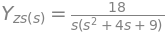

Zero-input respons


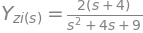

Total respons


Zero-state i tidsdomænet


Zero-input i tidsdomænet


Total respons i tidsdomænet



Initial- og finalværdi
Initial/final value check for Y_zs(s)
----------------------------------------
Initialværdi:


Finalværdi:



Initial/final value check for Y_zi(s)
----------------------------------------
Initialværdi:


Finalværdi:



Initial/final value check for Y_total(s)
----------------------------------------
Initialværdi:


Finalværdi:


In [25]:
# Eksempler: #Højeste led længst til højre

res = zero_state_zero_input(
   a_coeffs=[9, 4, 1],     # y'' + 4y' + 9y
    b_coeffs=[18],          # 18x
    y0_minus=[2, 0],
    X_s=1/s                 # x(t)=u(t) # DU GIVER X(S) IKKE x(t)
)

#res = zero_state_zero_input(
#    a_coeffs=[16, 8, 1],    # y'' + 8y' + 16y
#    b_coeffs=[0],           # intet input efter t=0
#    y0_plus=[0, 32],
#    X_s=0
#)